In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel("D:/data/diabetes.xlsx")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
print(df.head())
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

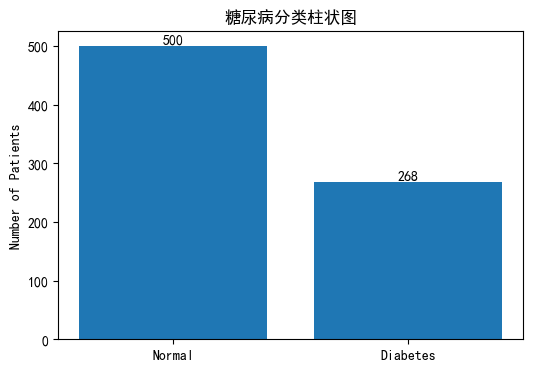

In [20]:
import matplotlib.pyplot as plt

counts = df['Outcome'].value_counts()
x = ['Normal', 'Diabetes']
y = counts.values  # 对应柱子高度

plt.figure(figsize=(6,4))
plt.bar(x, y)  # 简单绘制柱状图

plt.title("糖尿病分类柱状图")
plt.ylabel("Number of Patients")

# 在每个柱子顶部添加数值标签
for a, b in zip(x, y):
    plt.text(a, b + 0.5, str(b), ha='center', va='bottom', fontsize=10)

plt.show()


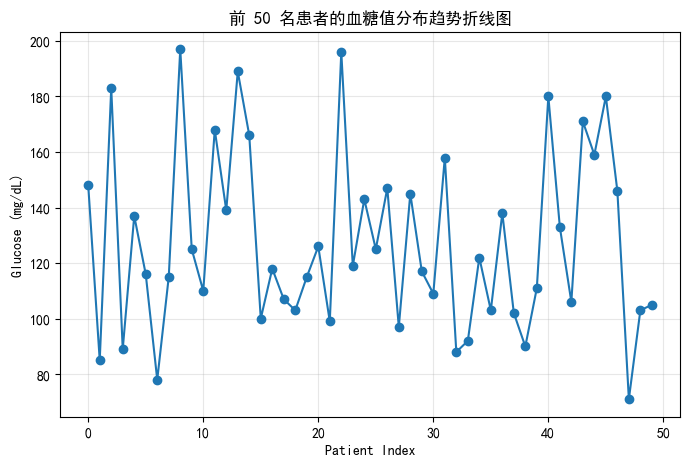

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df['Glucose'][:50], marker='o')

plt.title("前 50 名患者的血糖值分布趋势折线图")
plt.xlabel("Patient Index")
plt.ylabel("Glucose (mg/dL)")
plt.grid(True, alpha=0.3)  # 网格线设为浅灰色，避免遮挡折线
plt.show()

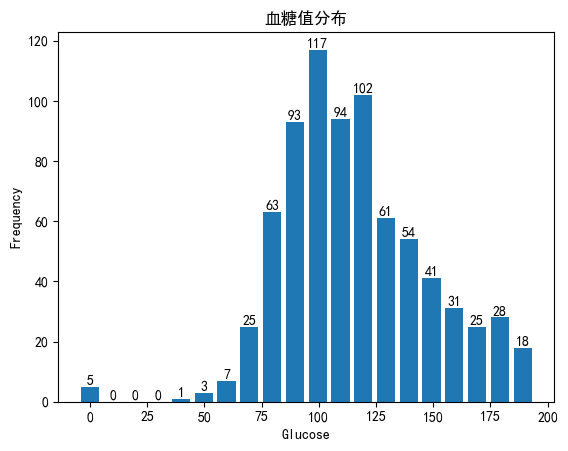

In [22]:
import matplotlib.pyplot as plt

# 绘制直方图，并获取频数和边界
counts, bins, patches = plt.hist(df['Glucose'], bins=20, rwidth=0.8, align='left' )

plt.title("血糖值分布")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

# 在每个柱子顶部添加数据标签
for count, patch in zip(counts, patches):
    plt.text(patch.get_x() + patch.get_width()/2,  # 横坐标：柱子中心
             count,                                # 纵坐标：柱子高度
             str(int(count)),                       # 标签内容
             ha='center', va='bottom', fontsize=10)

plt.show()



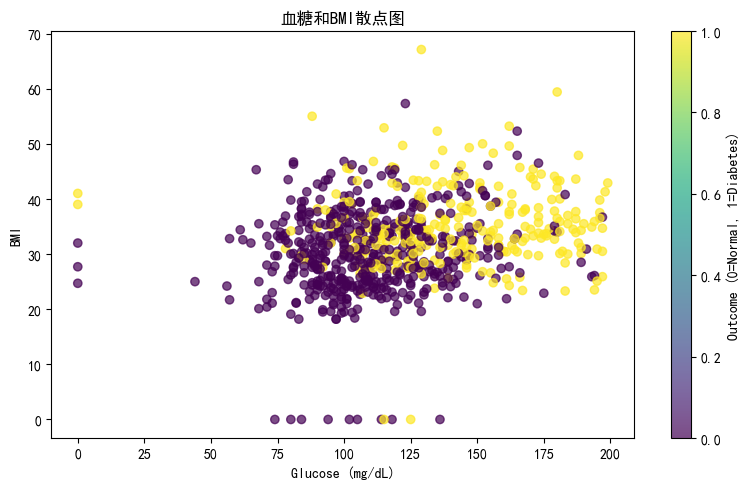

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 获取类别
colors = df['Outcome']

plt.figure(figsize=(8,5))

# 使用灰度配色
scatter = plt.scatter(df['Glucose'], 
                      df['BMI'], 
                      c=colors,   
                      alpha=0.7,
                      vmin=0, vmax=1)  # 仅新增这一行代码，实现颜色匹配

plt.title("血糖和BMI散点图")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI")

# 添加颜色条
cbar = plt.colorbar(scatter)
cbar.set_label('Outcome (0=Normal, 1=Diabetes)')

plt.tight_layout()
plt.show()



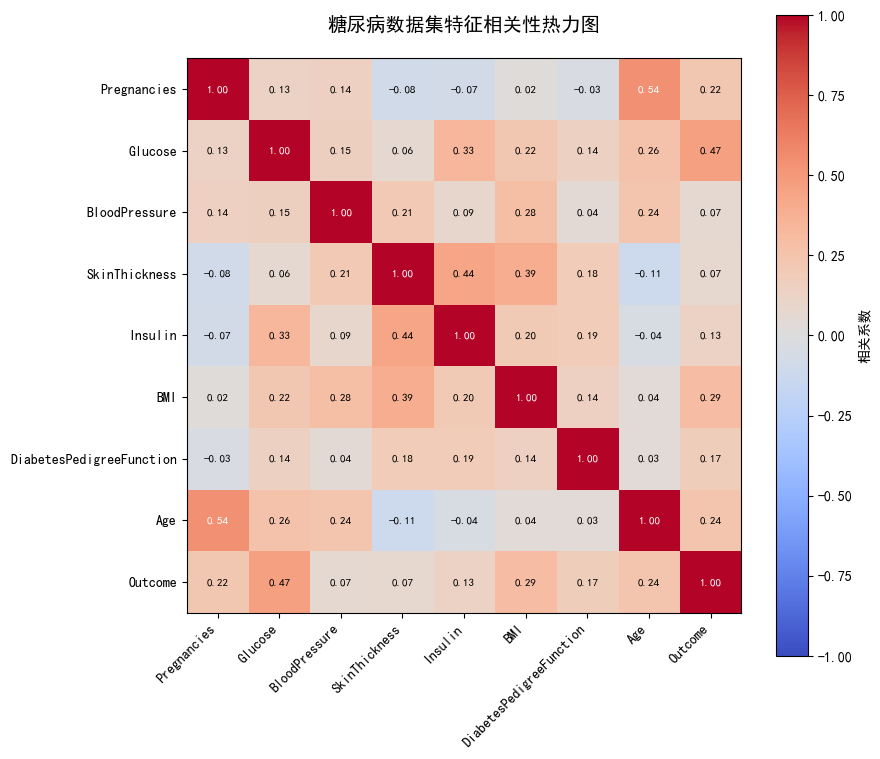

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("D:/data/diabetes.xlsx")

# 自动提取所有数值型特征
numeric_cols = df.select_dtypes(include=[np.number]).columns 
X = df.select_dtypes(include=[np.number]).values
correlation_matrix = np.corrcoef(X.T)

# 根据特征数量自动调整图像大小
n = correlation_matrix.shape[0]
plt.figure(figsize=(n, n))

plt.imshow(correlation_matrix,
           interpolation='nearest')

im = plt.imshow(
    correlation_matrix,
    interpolation='nearest',
    cmap='coolwarm',  
    vmin=-1, vmax=1 
)
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label('相关系数', fontsize=10)

# 6. 标注每个格子的相关系数（保留2位小数）
for i in range(n):
    for j in range(n):
        text = plt.text(
            j, i, f'{correlation_matrix[i, j]:.2f}',
            ha="center", va="center", color="black" if abs(correlation_matrix[i, j]) < 0.5 else "white",
            fontsize=8  # 根据特征数量自动适配字体大小
        )

plt.xticks(range(n), numeric_cols, rotation=45, ha='right')  # 旋转标签避免重叠
plt.yticks(range(n), numeric_cols)

plt.title('糖尿病数据集特征相关性热力图', fontsize=14, pad=20)
plt.tight_layout()  # 自动调整布局，防止标签被截断

plt.show()

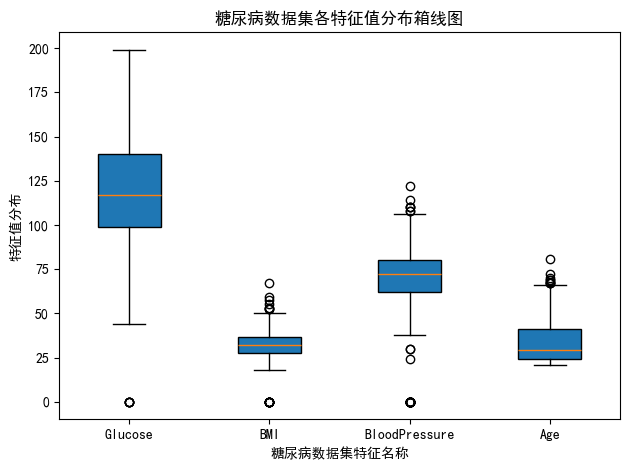

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 数据
df = pd.read_excel("D:/data/diabetes.xlsx")

# 选择需要绘制箱线图的数值特征
features = ['Glucose', 'BMI', 'BloodPressure', 'Age']

# 绘制箱线图
plt.boxplot(df[features],
            vert=True,                # 垂直箱线图
            patch_artist=True)
plt.xticks(range(1, len(features)+1), features)

plt.xlabel('糖尿病数据集特征名称')
plt.ylabel('特征值分布')
plt.title('糖尿病数据集各特征值分布箱线图')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.tight_layout()
plt.show()

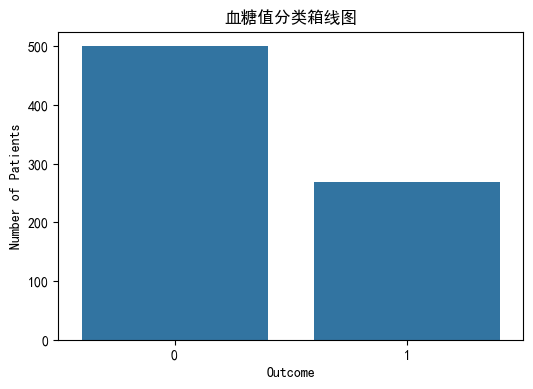

In [35]:
 
import seaborn as sns 
import matplotlib.pyplot as plt 

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Outcome")

plt.title("血糖值分类箱线图")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()


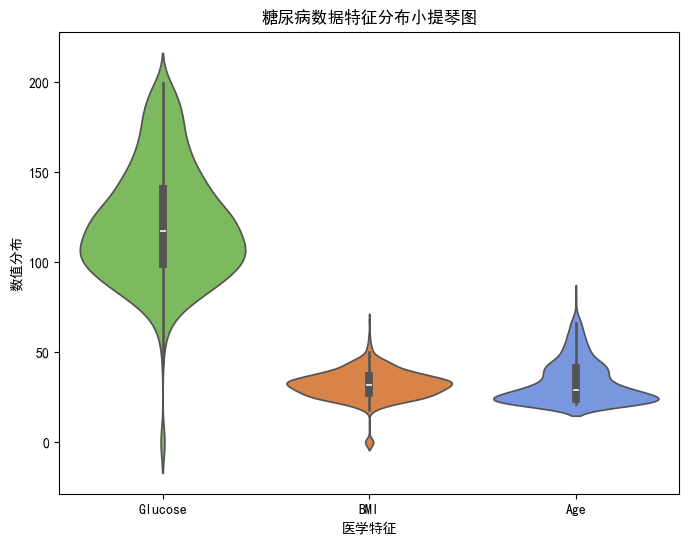

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataframe = pd.read_excel("D:/data/diabetes.xlsx")
species_colors = ['#78C850', '#F08030', '#6890F0']
plt.figure(figsize=(8,6))

sns.violinplot(
    data=dataframe[['Glucose', 'BMI', 'Age']],
    palette=species_colors
)

# （4）设置图表参数
plt.title("糖尿病数据特征分布小提琴图")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.xlabel("医学特征")
plt.ylabel("数值分布")

plt.show()


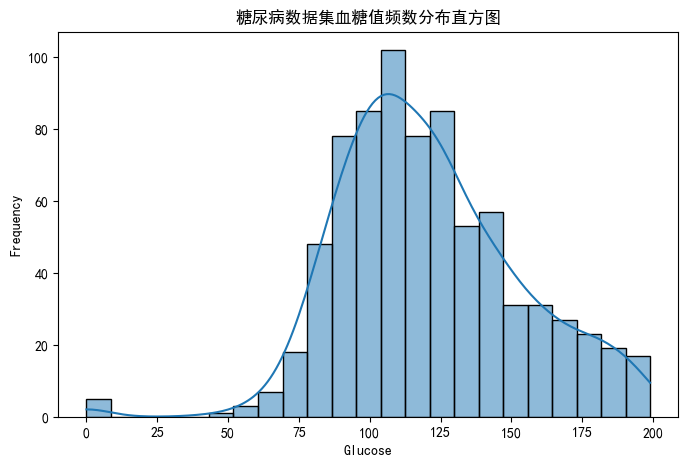

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Glucose"], kde=True)

plt.title("糖尿病数据集血糖值频数分布直方图")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()


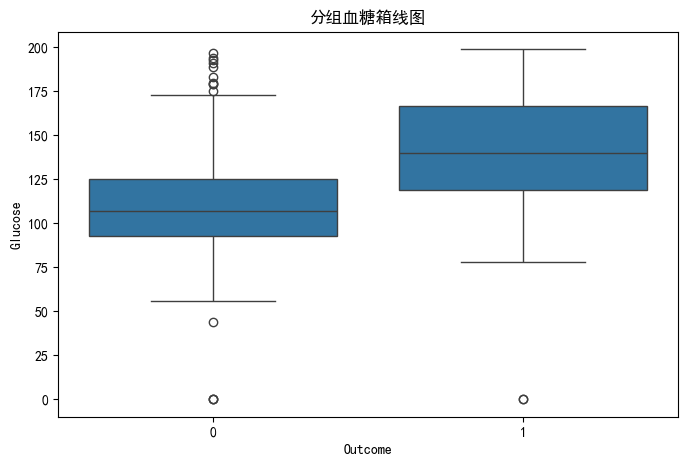

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Outcome", y="Glucose")

plt.title("分组血糖箱线图")
plt.xlabel("Outcome")
plt.ylabel("Glucose")

plt.show()


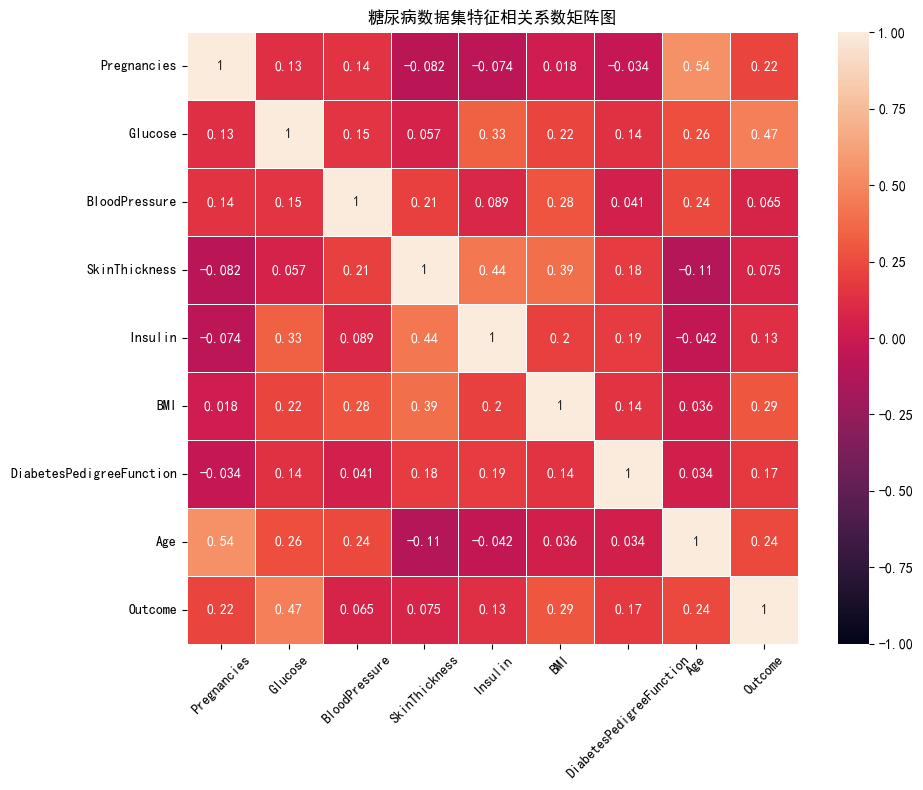

In [13]:
import pandas as pd
df = pd.read_excel("D:/data/diabetes.xlsx")
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,          # 显示相关系数数值
            vmin=-1, vmax=1,     # 固定相关系数范围
            linewidths=0.5,      # 添加网格线
            square=True)         # 每个格子为正方形
plt.title("糖尿病数据集特征相关系数矩阵图")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



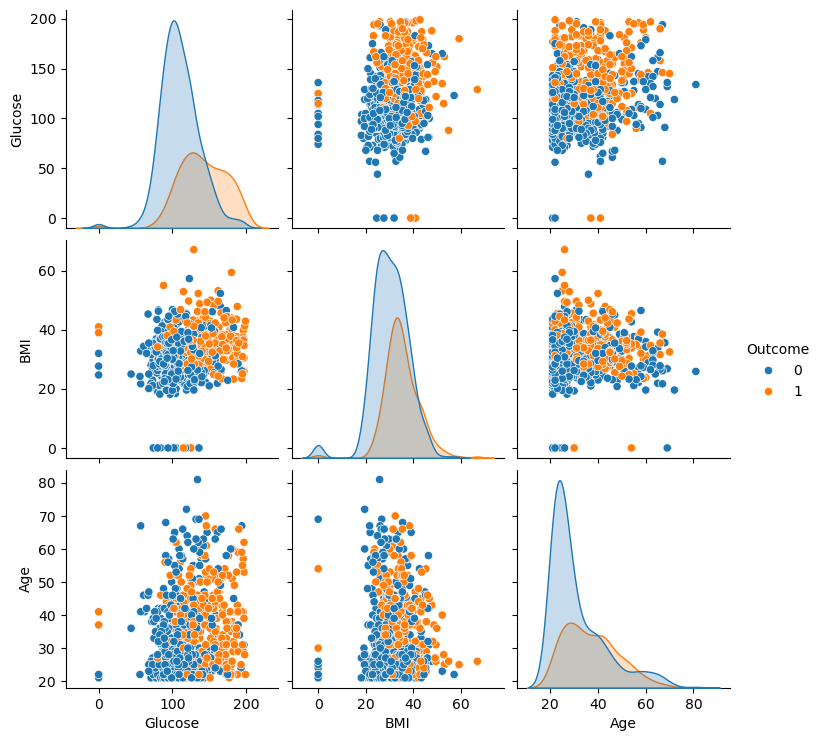

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 加载数据
dataframe = pd.read_excel("D:/data/diabetes.xlsx")

# 绘制成对关系图
sns.pairplot(
    dataframe[['Glucose', 'BMI', 'Age', 'Outcome']],
    hue='Outcome',
    palette='tab10'   # 自动适配类别数量
)

plt.show()

